<a href="https://colab.research.google.com/github/PreethiR091/ML-Lab/blob/main/Preethi_R_24BAD091_ML_Ex_no_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SCENARIO 1 – (Bagging)

Problem Statement:

    Predict whether a patient has diabetes.

Dataset:

    Diabetes Dataset

Target Variable:

    Outcome (0 = No Diabetes, 1 = Diabetes)

Input Features:

    Glucose, BMI, Age, Blood Pressure, etc.

IN-LAB TASKS

    •	Load dataset
    •	Train Decision Tree
    •	Apply BaggingClassifier
    •	Compare accuracy
Visualization

    •	Accuracy comparison bar graph
    •	Confusion matrix


Preethi R 24BAD091

Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


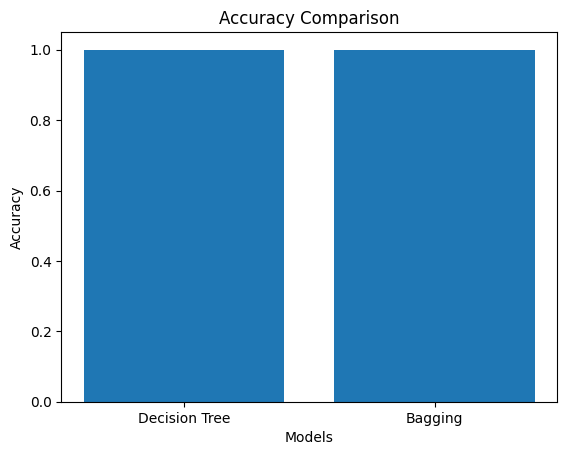

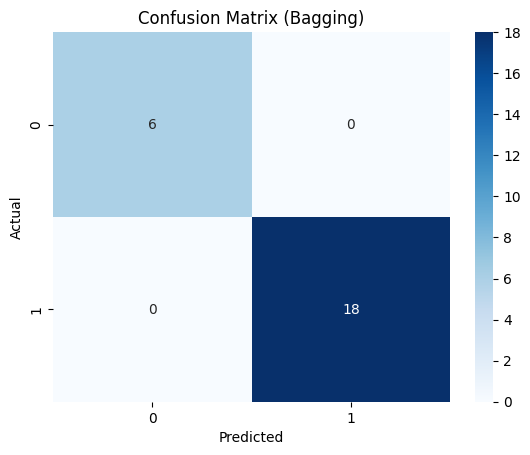

In [1]:
print("Preethi R 24BAD091\n")
# 1. Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load dataset
data = pd.read_csv("diabetes_bagging.csv")

# 3. Split data
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Add random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# 5. Bagging
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

# 6. Accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_bag = accuracy_score(y_test, y_pred_bag)

print("Decision Tree Accuracy:", acc_dt)
print("Bagging Accuracy:", acc_bag)

# 7. Bar Graph
plt.figure()
plt.bar(["Decision Tree", "Bagging"], [acc_dt, acc_bag])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.show()

# 8. Confusion Matrix
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_bag),
            annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Bagging)")
plt.show()

SCENARIO 2 – (Boosting-AdaBoost, Gradient Boosting)

Problem Statement:

    Predict whether a customer will churn.

Dataset:

    Telco Customer Churn Dataset

Target Variable:

    Churn (Yes/No)

Input Features:

    Tenure, Monthly Charges, Contract Type

IN-LAB TASKS

    •	Train AdaBoost
    •	Train Gradient Boosting
    •	Compare performance
Visualization

    •	ROC Curve
    •	Feature Importance plot


Preethi R 24BAD091

Original values: [0 1]
After cleaning: (120, 5)
y_test values: [0 1]


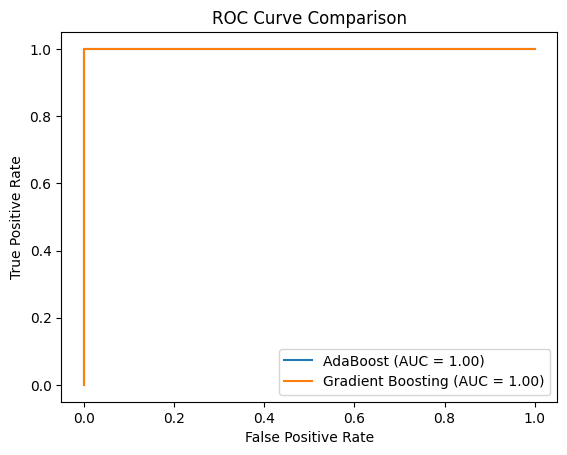

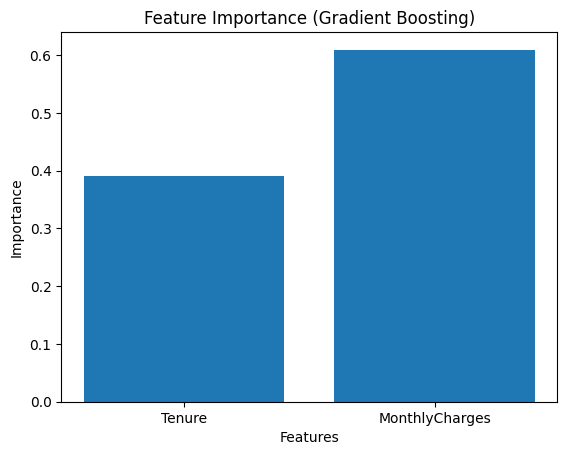

AdaBoost AUC: 1.0
Gradient Boosting AUC: 1.0


In [2]:
print("Preethi R 24BAD091\n")
# 1. Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 2. Load dataset
data = pd.read_csv("churn_boosting.csv")

# 3. Check original values
print("Original values:", data['Churn'].unique())

# 4. Preprocessing
if data['Churn'].dtype == 'object':
    data['Churn'] = data['Churn'].astype(str).str.strip().str.lower()
    data['Churn'] = data['Churn'].replace({'yes': 1, 'no': 0})

# Remove invalid rows only
data = data[data['Churn'].notna()]

print("After cleaning:", data.shape)

# 5. Features & target
X = data[['Tenure', 'MonthlyCharges']]
y = data['Churn']

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("y_test values:", y_test.unique())

# 7. AdaBoost Model
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict_proba(X_test)[:, 1]

# 8. Gradient Boosting Model
gb = GradientBoostingClassifier(n_estimators=50, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict_proba(X_test)[:, 1]

# 9. ROC Curve
fpr1, tpr1, _ = roc_curve(y_test, y_pred_ada)
fpr2, tpr2, _ = roc_curve(y_test, y_pred_gb)

auc_ada = auc(fpr1, tpr1)
auc_gb = auc(fpr2, tpr2)

plt.figure()
plt.plot(fpr1, tpr1, label="AdaBoost (AUC = %.2f)" % auc_ada)
plt.plot(fpr2, tpr2, label="Gradient Boosting (AUC = %.2f)" % auc_gb)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# 10. Feature Importance (Gradient Boosting)
plt.figure()
plt.bar(X.columns, gb.feature_importances_)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance (Gradient Boosting)")
plt.show()

# 11. Print Results
print("AdaBoost AUC:", auc_ada)
print("Gradient Boosting AUC:", auc_gb)

SCENARIO 3 – Random Forest

Problem Statement:

    Predict whether a person earns >50K salary.
Dataset:

    Adult Income Dataset
Target Variable:

    Income (>50K or <=50K)
Input Features:

    Age, Education, Occupation, Hours-per-week

IN-LAB TASKS

    •	Train Random Forest
    •	Tune number of trees
    •	Evaluate model
Visualization

    •	Feature Importance
    •	Accuracy vs Number of Trees graph


Preethi R 24BAD091

Original values: [0 1]
After cleaning: (120, 5)


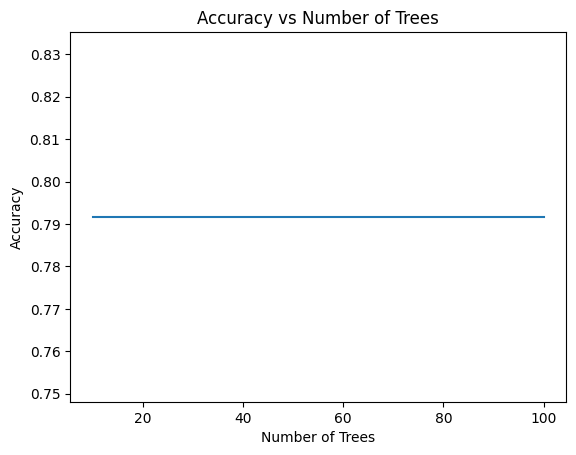

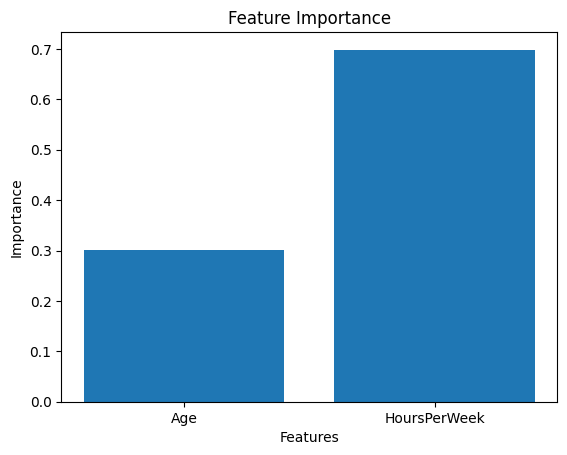

Trees: 10, Accuracy: 0.7916666666666666
Trees: 50, Accuracy: 0.7916666666666666
Trees: 100, Accuracy: 0.7916666666666666


In [3]:
print("Preethi R 24BAD091\n")
# 1. Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 2. Load dataset
data = pd.read_csv("income_random_forest.csv")

# Check original values
print("Original values:", data['Income'].unique())

# 3. Preprocessing (
data['Income'] = data['Income'].astype(str).str.strip().str.replace('.', '', regex=False)
data['Income'] = data['Income'].str.lower()
data['Income'] = data['Income'].replace({'>50k':1, '<=50k':0})

# Remove invalid rows
data = data[data['Income'].notna()]

print("After cleaning:", data.shape)

# 4. Features & target
X = data[['Age','HoursPerWeek']]
y = data['Income']

# 5. Train-test split (add random_state + stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. Train with different trees
trees = [10, 50, 100]
acc = []

for n in trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc.append(accuracy_score(y_test, y_pred))

# 7. Plot Accuracy vs Trees
plt.figure()
plt.plot(trees, acc)
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")
plt.show()

# 8. Feature Importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

plt.figure()
plt.bar(X.columns, rf.feature_importances_)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

# 9. Print results
for i in range(len(trees)):
    print(f"Trees: {trees[i]}, Accuracy: {acc[i]}")

SCENARIO 4 – Stacking

Problem Statement:

    Predict heart disease presence.
Dataset:

    Heart Disease Dataset
Target Variable:

    Presence of Heart Disease (0/1)
Input Features:

    Cholesterol, Max Heart Rate, Age

IN-LAB TASKS

    •	Train base models (Logistic Regression, SVM, Decision Tree)
    •	Combine using StackingClassifier
    •	Compare with individual models
Visualization

    •	Model comparison bar chart


Preethi R 24BAD091



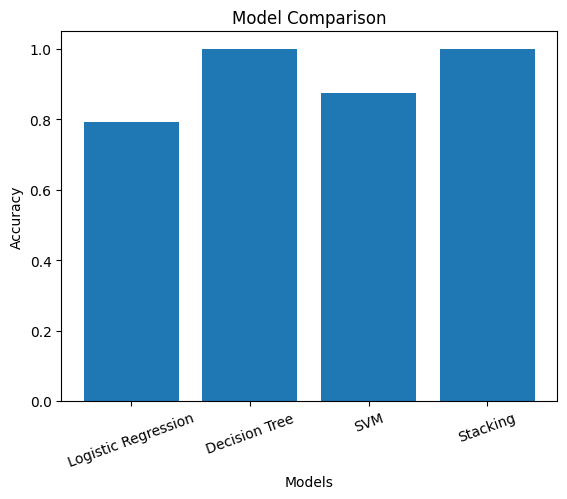

Logistic Regression Accuracy: 0.7916666666666666
Decision Tree Accuracy: 1.0
SVM Accuracy: 0.875
Stacking Accuracy: 1.0


In [4]:
print("Preethi R 24BAD091\n")
# 1. Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 2. Load dataset
data = pd.read_csv("heart_stacking.csv")

# 3. Split (FIXED)
X = data.drop("HeartDisease", axis=1)
y = data["HeartDisease"]

# 4. Train-test split (with stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 5. Base models
estimators = [
    ('lr', LogisticRegression()),
    ('dt', DecisionTreeClassifier()),
    ('svm', SVC(probability=True))
]

# 6. Train base models + collect accuracy
models = ['Logistic Regression', 'Decision Tree', 'SVM', 'Stacking']
scores = []

for name, model in estimators:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

# 7. Stacking model
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)
stack.fit(X_train, y_train)

y_pred_stack = stack.predict(X_test)
scores.append(accuracy_score(y_test, y_pred_stack))

# 8. Plot comparison
plt.figure()
plt.bar(models, scores)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.show()

# 9. Print results
for i in range(len(models)):
    print(models[i], "Accuracy:", scores[i])

SCENARIO 5 – SMOTE

Problem Statement:

    Detect fraudulent transactions.
Dataset:

    Credit Card Fraud Detection Dataset
Target Variable:

    Fraud (0 = Normal, 1 = Fraud)
Input Features:

    Transaction Amount, Time, PCA features

IN-LAB TASKS

    •	Check class imbalance
    •	Apply SMOTE
    •	Train model before & after SMOTE
    •	Compare performance

Visualization

    •	Class distribution (Before & After SMOTE)
    •	Precision-Recall Curve


Preethi R 24BAD091

Class distribution BEFORE SMOTE:
Fraud
0    110
1     10
Name: count, dtype: int64

Class distribution AFTER SMOTE:
Fraud
1    88
0    88
Name: count, dtype: int64

Accuracy BEFORE SMOTE: 0.9166666666666666
Accuracy AFTER SMOTE: 0.8333333333333334


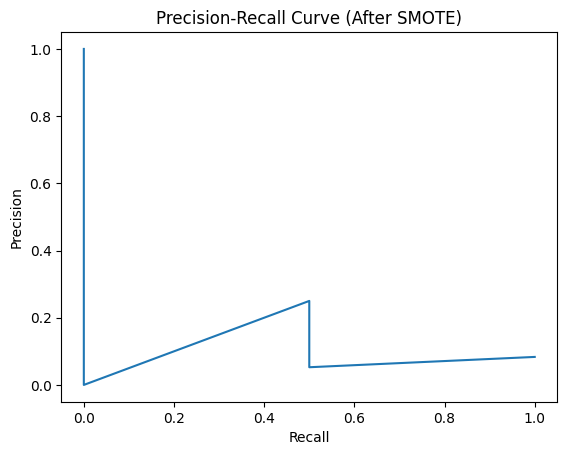

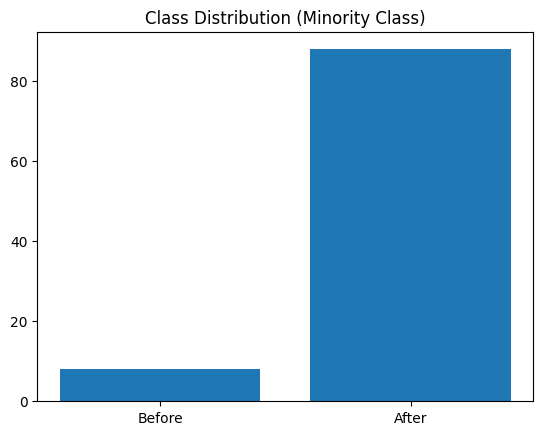

In [5]:
print("Preethi R 24BAD091\n")
# 1. Import libraries
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, accuracy_score
import matplotlib.pyplot as plt

# 2. Load dataset
data = pd.read_csv("fraud_smote.csv")

# 3. Features & target
X = data.drop("Fraud", axis=1)
y = data["Fraud"]

# 4. Check class imbalance
print("Class distribution BEFORE SMOTE:")
print(y.value_counts())

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# BEFORE SMOTE
rf_before = RandomForestClassifier(random_state=42)
rf_before.fit(X_train, y_train)

y_pred_before = rf_before.predict(X_test)
acc_before = accuracy_score(y_test, y_pred_before)

# APPLY SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print("\nClass distribution AFTER SMOTE:")
print(y_res.value_counts())

# AFTER SMOTE
rf_after = RandomForestClassifier(random_state=42)
rf_after.fit(X_res, y_res)

y_pred_after = rf_after.predict(X_test)
acc_after = accuracy_score(y_test, y_pred_after)

# ACCURACY COMPARISON
print("\nAccuracy BEFORE SMOTE:", acc_before)
print("Accuracy AFTER SMOTE:", acc_after)

# PRECISION-RECALL CURVE
y_scores = rf_after.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (After SMOTE)")
plt.show()

# CLASS DISTRIBUTION GRAPH
plt.figure()
plt.bar(['Before', 'After'],
        [y_train.value_counts()[1], y_res.value_counts()[1]])
plt.title("Class Distribution (Minority Class)")
plt.show()